In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer

In [2]:
data = load_breast_cancer()

In [3]:
df = pd.DataFrame(data = data['data'], columns=data.feature_names)
df['target'] = data['target']
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [4]:
df['target'].value_counts()

target
1    357
0    212
Name: count, dtype: int64

In [5]:
x = df.iloc[:, :-1].values
y = df['target'].values

In [6]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [7]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))


In [8]:
def update_weights(x, y, weights, learning_rate, z):
    m = len(y)
    dw = (1 / m) * np.dot(x.T, (z - y))
    weights -= learning_rate * dw
    return weights


In [9]:
def update_bias(y, z, bias, learning_rate):
    m = len(y)
    db = (1 / m) * np.sum(z - y)
    bias -= learning_rate * db
    return bias

In [10]:
def perceptron(x, bias, weights):
    z = np.dot(x, weights) + bias
    y_pred = sigmoid(z)
    y_pred_cls = [1 if i > 0.5 else 0 for i in y_pred]
    return y_pred_cls
    

In [11]:
def accuracy(y_actual, y_pred):
    acc = np.sum(y_actual == y_pred) / len(y_actual)
    return acc

In [12]:
from operator import le

learning_rate = 0.001
weights = np.zeros(x_train.shape[1])
bias = 0
for i in range(1000):
    pred = perceptron(x_train, bias, weights)
    weights = update_weights(x_train, y_train, weights, learning_rate, pred)
    bias = update_bias(y_train, pred, bias, learning_rate)


C:\Users\Ahmed Morad\AppData\Local\Temp\ipykernel_14216\1956533664.py:2: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-x))


In [13]:
pred_test = perceptron(x_test, bias, weights)
print("Accuracy:", accuracy(y_test, pred_test))


Accuracy: 0.9473684210526315


C:\Users\Ahmed Morad\AppData\Local\Temp\ipykernel_14216\1956533664.py:2: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-x))


In [14]:
pred_train = perceptron(x_train, bias, weights)
print("Accuracy:", accuracy(y_train, pred_train))


Accuracy: 0.8813186813186813


C:\Users\Ahmed Morad\AppData\Local\Temp\ipykernel_14216\1956533664.py:2: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-x))


In [16]:
%pip install networkx

   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   -------------------------------

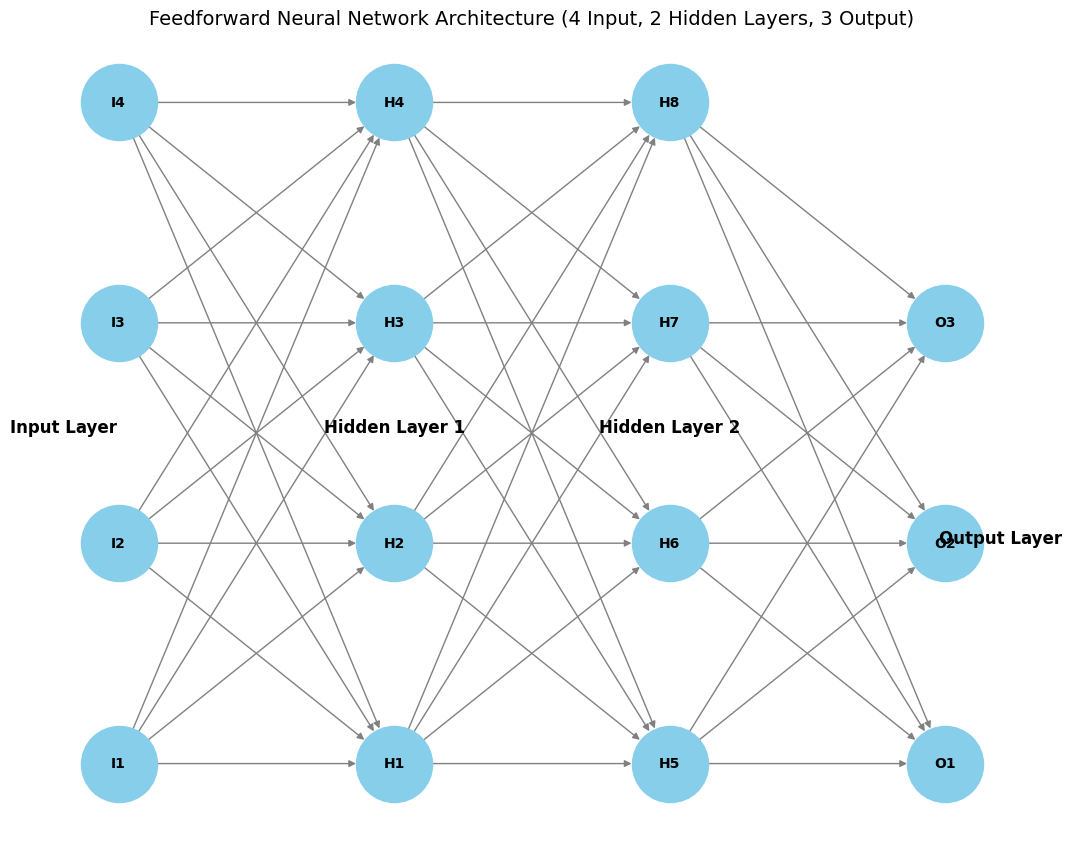

In [17]:

import matplotlib.pyplot as plt
import networkx as nx

# Create a graph object
G = nx.DiGraph()

# Define nodes for the layers
input_layer = ['I1', 'I2', 'I3', 'I4']  # 4 input nodes
hidden_layer_1 = ['H1', 'H2', 'H3', 'H4']  # 4 nodes in the first hidden layer
hidden_layer_2 = ['H5', 'H6', 'H7', 'H8']  # 4 nodes in the second hidden layer
output_layer = ['O1', 'O2', 'O3']  # 3 output nodes

# Add nodes to the graph
G.add_nodes_from(input_layer)
G.add_nodes_from(hidden_layer_1)
G.add_nodes_from(hidden_layer_2)
G.add_nodes_from(output_layer)

# Connect nodes between layers (Feedforward connections)
for input_node in input_layer:
    for hidden_node in hidden_layer_1:
        G.add_edge(input_node, hidden_node)

for hidden_node_1 in hidden_layer_1:
    for hidden_node_2 in hidden_layer_2:
        G.add_edge(hidden_node_1, hidden_node_2)

for hidden_node_2 in hidden_layer_2:
    for output_node in output_layer:
        G.add_edge(hidden_node_2, output_node)

# Define position of nodes for layers
pos = {
    'I1': (0, 1), 'I2': (0, 2), 'I3': (0, 3), 'I4': (0, 4),
    'H1': (1, 1), 'H2': (1, 2), 'H3': (1, 3), 'H4': (1, 4),
    'H5': (2, 1), 'H6': (2, 2), 'H7': (2, 3), 'H8': (2, 4),
    'O1': (3, 1), 'O2': (3, 2), 'O3': (3, 3)
}

# Draw the graph
plt.figure(figsize=(10, 8))
nx.draw(G, pos, with_labels=True, node_size=3000, node_color='skyblue', font_size=10, font_weight='bold', edge_color='gray')

# Label the layers
plt.text(-0.2, 2.5, 'Input Layer', fontsize=12, fontweight='bold', ha='center')
plt.text(1, 2.5, 'Hidden Layer 1', fontsize=12, fontweight='bold', ha='center')
plt.text(2, 2.5, 'Hidden Layer 2', fontsize=12, fontweight='bold', ha='center')
plt.text(3.2, 2, 'Output Layer', fontsize=12, fontweight='bold', ha='center')

# Display the plot
plt.title('Feedforward Neural Network Architecture (4 Input, 2 Hidden Layers, 3 Output)', fontsize=14)
plt.axis('off')
plt.show()
